<a href="https://colab.research.google.com/github/aryaaaa-exe/Audio-Deepfake-Detection/blob/main/PS3DT_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALING REQUIRED PACKAGES**

In [1]:
!pip install scipy soundfile torch torchvision torchaudio tqdm
!pip install scikit-learn

In [ ]:
!pip install datasets

import torch

if torch.cuda.is_available():
    print(" GPU is connected!")
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("❌ GPU is NOT connected. Using CPU.")

**LOADING AND UNDERSTANDING DATASET**

In [2]:
#Install the Kaggle CLI(only needed once per session)
!pip install -q kaggle

#Upload the kaggle.json API key (run this cell once)
from google.colab import files
uploaded=files.upload()

#Move the key to the right place and protect it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Delete any previously extracted (possibly corrupted) folder
!rm -rf /content/ASVspoof2019

#Download the ASVspoof‑2019 dataset from Kaggle(skip download if the zip is already on disk)
import os
zip_path="asvpoof-2019-dataset.zip"
if not os.path.exists(zip_path):
    !kaggle datasets download -d awsaf49/asvpoof-2019-dataset

#Inspect disk usage(optional, run once)
!df -h
!du -sh /content/* | sort -hr

#Extract the zip file – overwrite silently, no prompts
!unzip -q -o "$zip_path" -d ASVspoof2019

#Verify that the expected training folder is present
train_dir="/content/ASVspoof2019/LA/LA/ASVspoof2019_LA_train/flac"
if os.path.isdir(train_dir):
    print(" Extraction successful – training files are ready.")
else:
    raise RuntimeError(
        " Extraction incomplete! "
        "The expected folder was not found. "
        "Please re‑run the cell."
    )

#Delete the zip file to free up space
!rm -f "$zip_path"

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
100% 23.6G/23.6G [21:03<00:00, 20.0MB/s]

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   71G   43G  63% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   74G   46G  62% /opt/bin/.nvidia
tmpfs           6.4G  192K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
24G	/content/asvpoof-2019-dataset.zip
55M	/content/sample_data
4.0K	/content/kaggle.json
 Extraction successful – training files are ready.


In [3]:
#seeing where our data is
import os

def print_tree(startpath, max_depth=3):
    for root,dirs,files in os.walk(startpath):
        level=root.replace(startpath, '').count(os.sep)
        if level>max_depth:
            continue
        indent=' ' * 4 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent=' ' * 4 * (level + 1)
        # Just print a couple of files to keep it short
        for f in files[:2]:
            print(f'{subindent}{f}')
        if len(files)>2:
            print(f'{subindent}...')

print_tree("/content/ASVspoof2019/LA")

LA/
    LA/
        README.LA.txt
        ASVspoof2019_LA_train/
            LICENSE.txt
            flac/
                LA_T_5720841.flac
                LA_T_7473916.flac
                ...
        ASVspoof2019_LA_eval/
            LICENSE.txt
            flac/
                LA_E_1103494.flac
                LA_E_7703891.flac
                ...
        ASVspoof2019_LA_asv_scores/
            ASVspoof2019.LA.asv.dev.gi.trl.scores.txt
            ASVspoof2019.LA.asv.eval.gi.trl.scores.txt
        ASVspoof2019_LA_asv_protocols/
            ASVspoof2019.LA.asv.eval.male.trl.txt
            ASVspoof2019.LA.asv.dev.female.trl.txt
            ...
        ASVspoof2019_LA_dev/
            LICENSE.txt
            flac/
                LA_D_3070334.flac
                LA_D_7230852.flac
                ...
        ASVspoof2019_LA_cm_protocols/
            ASVspoof2019.LA.cm.eval.trl.txt
            ASVspoof2019.LA.cm.dev.trl.txt
            ...


In [4]:
#inspecting the audio(Now reading directly from the Kaggle folder)
import librosa
import os

#Get the first file ID from the training protocol
protocol_path="/content/ASVspoof2019/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
with open(protocol_path,"r") as f:
    first_file_id=f.readline().strip().split()[1]

audio_path=f"/content/ASVspoof2019/LA/LA/ASVspoof2019_LA_train/flac/{first_file_id}.flac"

# Load the audio using librosa
waveform,sampling_rate=librosa.load(audio_path,sr=None)

print("Waveform shape: ",waveform.shape)
print("Sampling rate: ",sampling_rate)

Waveform shape:  (55329,)
Sampling rate:  16000


-Using the given outputs we can compute the duration of the given audio. We can do the same for other audio itself.

-We care about the waveform length because different audio files have different durations and Neural-Networks cannot directly process batches of variable-length inputs.

-So, before training, we'll need a strategy to make the inputs compatible by following exactly the preprocessing described in the PS3DT paper.

**AUDIO PRE-PROCESSING**

In [5]:
#Audio Pre-Processing

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

#The desired length of every audio in the paper was 5.12 seconds and the desired sampling rate was 16kHz.
desired_seconds=5.12
sr=16000
target_length=int(desired_seconds*sr) #desired number of samples(81,920)

#According to the paper, in cases of undesired audio lengths, the paper repeats the speech signal in case it is shorter and truncates to the first desired seconds in case the audio is larger.
def preprocess_audio(waveform,target_length):
  current_length=len(waveform)
  if current_length==0: #handling an edge case
    raise ValueError("Encountered an empty audio waveform.")
  if current_length<target_length:
    repeat_factor=int(np.ceil(target_length/current_length)) #the number of time the audio will be repeated
    waveform=np.tile(waveform,repeat_factor) #construct a new array by repeating an existing array a specified number of times.
  waveform=waveform[:target_length] #truncate(similar to slicing)
  return waveform


In [6]:
waveform=preprocess_audio(
    waveform,
    target_length
)

print("Waveform length:", len(waveform))
print("Expected length:", target_length)
print("Sampling rate:", sr)

Waveform length: 81920
Expected length: 81920
Sampling rate: 16000


**FEATURE EXTRACTION**

In [7]:
import IPython.display as ipd
#To load the audio for feature extraction visualization
import librosa

audio_path=f"/content/ASVspoof2019/LA/LA/ASVspoof2019_LA_train/flac/{first_file_id}.flac"
waveform,sr=librosa.load(audio_path,sr=None)

In [8]:
#Function For Feature Extraction
def extract_mel_spectrogram(waveform,sr):
  mel_spectrogram=librosa.feature.melspectrogram(
      y=waveform,
      sr=sr,
      n_fft=400, #the paper says "25 ms window" so 25ms=0.025sec. So, 0.025*sr=400
      hop_length=160, #the paper says "10 ms stride" so 10ms=0.01sec. So, 0.01*sr=160
      n_mels=80, #80-bin Log-Mel Spectrogram
      window='hann'
  )

  #Convert power spectrogram to log scale (dB)
  log_mel=librosa.power_to_db(
      mel_spectrogram,
      ref=np.max
  )

  #Keep only the first 512 time frames
  log_mel=log_mel[:, :512]
  #without this line we were getting shape as (80*513) due to centre=True padding of librosa


  return log_mel

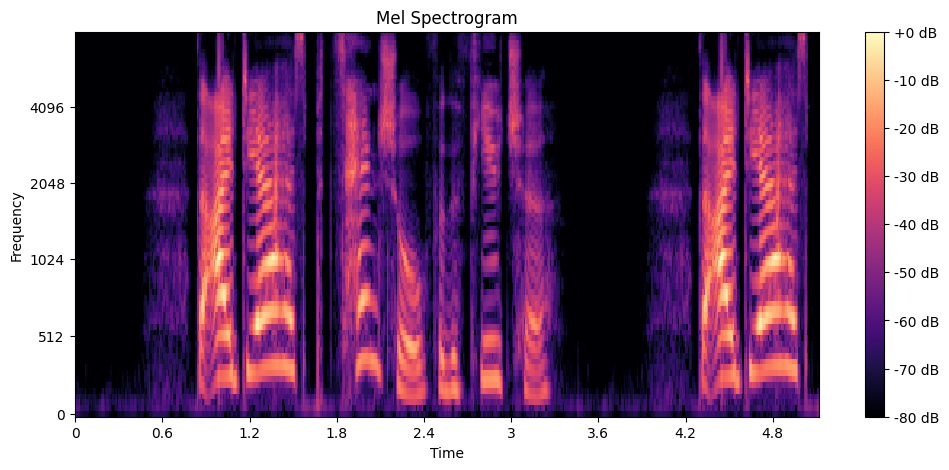

In [9]:
#obtaining a waveform of a preprocessed data
waveform=preprocess_audio(
    waveform,
    target_length
)

display(ipd.Audio(waveform,rate=sr)) #playing original audio

#Plotting the Mel Spectrogram
mel_spectrogram=extract_mel_spectrogram(waveform,sr)

plt.figure(figsize=(12,5))
librosa.display.specshow(
    mel_spectrogram,
    sr=sr,
    hop_length=160,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()


-The transformers take input in the form of vectors/embeddings. The output from above will not help us with transformers.

-So, our next step is to flatten each 16*16 patch into a vector of length 256, then pass it through a linear layer to obtain a 768-dimensional embedding before adding positional embeddings and feeding it to the transformer.

In [ ]:
import torch

#Creating Patches
def create_patches(mel_spectrogram):
  patch_size=16
  patches=[] #empty list

  for i in range(0,mel_spectrogram.shape[0],patch_size): #0,16,32,48,64; starting rows
    for j in range(0,mel_spectrogram.shape[1],patch_size): #0,16,32,...,96; (32 positions in total)
      #Extract path
      patch=mel_spectrogram[
          i:i+patch_size,
          j:j+patch_size
      ]
      #storing the patches in a list
      patches.append(patch)

  #list converted to numpy array to give a shape of (patch number,size,size)
  #neural networks expect array/tensors so conversion is useful
  patches=np.array(patches)

  #Converts Numpy to Tensor
  patches=torch.tensor(
      patches,
      dtype=torch.float32 #Neural networks perform calculations using floating-point numbers so it is needed to specify the type
  )

  return patches

#Flattening the patches
def flatten_patches(patches):
  patches= patches.reshape(patches_before.shape[0], -1)
  #print("After Flattening: ", patches.shape)
  return patches


# data preprocessing

In [ ]:
import torch.nn as nn
#Preparing the patches for input in the transformer
class EncoderInput(nn.Module):
  def __init__(self,num_patches=160,d_model=768,patch_dim=256):
    super().__init__()

    self.patch_embed=nn.Linear( #Creates a Fully Connected layer where right now the weights are random
        in_features=patch_dim, #Each flattened patch contains 256 values
        out_features=d_model #every patch is converted into a 768 dimensional embedding
    )

    #returns a tensor filled with random numbers
    self.pos_embed=nn.Parameter(
        torch.randn(num_patches,d_model)
    )

  def forward(self,x):#x-> patches
    embedded_patches=self.patch_embed(x)
    output=embedded_patches+self.pos_embed
    return output



# encoder


In [ ]:
#Transformer Encoder Block as exactly same as used in msm-mae model
from timm.models.vision_transformer import DropPath, Mlp

class AttentionKBiasZero(nn.Module):
  #dim=embeddings=768,num_heads=nuber of attention heads; query and value have bias; dropout applied to attention weights and after the final projecttion.
  #Query and Value will be updated using learnable parameters, while intentionally leaving the Key projection without a learnable bias to match the pretrained BEiT/MAE architecture used in PS3DT.
    def __init__(self,dim,num_heads=8,qkv_bias=True,attn_drop=0.,proj_drop=0.):
        super().__init__()
        assert dim % num_heads==0 #dim should be divisible by num_heads
        self.num_heads=num_heads #stores number of heads
        head_dim=dim//num_heads #dimension of head
        self.scale=head_dim**-0.5 #scaling factor used to prevent unstable gradient

        self.qkv=nn.Linear(dim,dim*3,bias=False) #one large Linear layer computes all query,key and value together; bias is false because we will manually create the bias
        #creating the learnable bias vectors. these bias vectors will later be added to the Query and Value projections.
        if qkv_bias:
            self.q_bias=nn.Parameter(torch.zeros(dim)) #creates 768 learnable parameters initialised to zero
            self.v_bias=nn.Parameter(torch.zeros(dim))
        else:
            self.q_bias=None
            self.v_bias=None
        #dropouts to prevent overfitting
        self.attn_drop=nn.Dropout(attn_drop)
        self.proj=nn.Linear(dim,dim)
        self.proj_drop=nn.Dropout(proj_drop)

    def forward(self,x,return_attention=False):
        B,N,C=x.shape #input shape: batch size,no. of patches,embedding dim
        qkv_bias=None
        if self.q_bias is not None:         #(below)creates key bias=0
            qkv_bias=torch.cat((self.q_bias,torch.zeros_like(self.v_bias,requires_grad=False),self.v_bias)) #concatenate query,key and value bias
        qkv=nn.functional.linear(input=x,weight=self.qkv.weight,bias=qkv_bias) #linear projection
        qkv=qkv.reshape(B,N,3,self.num_heads,C//self.num_heads).permute(2, 0, 3, 1, 4) #transforms(reshapes) and permutes
        q,k,v=qkv.unbind(0) #splits and now q,k,v are separate tensors

        #attention scores
        attn=(q@k.transpose(-2,-1))*self.scale #Q.K^T and scale is (1/sqrt(dim))^2 to prevent unstable gradient
        attn=attn.softmax(dim=-1) #converts scores into probabilities
        attn=self.attn_drop(attn) #Randomly removes some attention weights during training.
        x=(attn@v).transpose(1,2).reshape(B,N,C) #weighted sum
        x=self.proj(x) #output projection
        x=self.proj_drop(x)
        if return_attention:
          return x,attn
        return x


class BlockKBiasZero(nn.Module):

    def __init__(self,dim,num_heads,mlp_ratio=4.,qkv_bias=True,drop=0.,attn_drop=0.,drop_path=0.,act_layer=nn.GELU,norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1=norm_layer(dim) #Layer normalization before attention.
        self.attn=AttentionKBiasZero(dim,num_heads=num_heads,qkv_bias=qkv_bias,attn_drop=attn_drop,proj_drop=drop)
        #Implementing stochastic depth:similar to Dropout, but instead of dropping individual neurons, it drops an entire layer during training.
        self.drop_path=DropPath(drop_path) if drop_path>0. else nn.Identity()
        self.norm2=norm_layer(dim) #LayerNorm before MLP.
        mlp_hidden_dim=int(dim*mlp_ratio)
        #creating feed forward network
        self.mlp=Mlp(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)

    def forward(self,x,return_attention=False):
        if return_attention:
            #layernorm->multihead-self attention
            x_att,attn=self.attn(self.norm1(x),return_attention=True)
            x=x+self.drop_path(x_att)
            x=x+self.drop_path(self.mlp(self.norm2(x)))
            return x,attn

        #layernorm->attention->droppath
        x=x+self.drop_path(self.attn(self.norm1(x)))
        #layernorm->mlp->droppath
        x=x+self.drop_path(self.mlp(self.norm2(x)))
        return x

In [ ]:
# we want to stack 12 encoder blocks as done in the paper
from functools import partial

class Encoder(nn.Module):
  def __init__(self,num_layers=12,d_model=768,num_heads=12):
    super().__init__() # Initialize nn.Module
    #When loading pretrained weights, PyTorch matches layer names and our dataset has "blocks.0","b;ocks.1", etc so renamed "layers" to "blocks"
    self.blocks=nn.ModuleList() #creates an empty list to store PyTorch layers
    for i in range(num_layers): #each iteration creates one transformer block
      self.blocks.append(
          BlockKBiasZero( #creates transformer block
              dim=d_model,
              num_heads=num_heads,
              mlp_ratio=4,
              qkv_bias=True,
              norm_layer=partial(nn.LayerNorm, eps=1e-6)
            )
      )

  def forward(self,x):
    for blk in self.blocks: #Passes output of one encoder into next encoder.
      x=blk(x)
    return x

In [ ]:
def concatenate(X):
    #X shape:(batch_size,160,768)

    B=X.shape[0] #BATCH Size
    #patches in a grid of 5*32
    num_freq_patch=5
    num_frame=32

    #5patch -> 1frames
    #(B,160,768)->(B,5,32,768) (reshaping)
    X_grid=X.view(B,num_freq_patch,num_frame,768)

    #(B,5,32,768)->(B,32,5,768)
    X_grid=X_grid.permute(0,2,1,3)

    #(B,32,5,768)->(B,32,3840)
    frame_vector=X_grid.reshape(B,num_frame,num_freq_patch*768)

    return frame_vector

# Encoder Output block


In [ ]:
class OutputBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential_1=nn.Sequential(
            nn.Linear(3840,768)
        )
        self.sequential_2=nn.Sequential(
            nn.Linear(768,256), #768 input and 256 neurrons
            nn.ReLU(),
            nn.Linear(256,2),
            #nn.Sigmoid() #no need of this anymore because our loss function has in built softmax func
        )

    def forward(self,x):
        x=concatenate(x) # 160 patches converted to 32frames
        x=self.sequential_1(x)# 3840 dim conveerted to 768 dim
        x=x.mean(dim=1)  # mean pooling across frames  # x has 768 dim
        x=self.sequential_2(x) # gives bonafied or synthetic prob
        return x



# ps3dt


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PS3DT(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder_input=EncoderInput()
    self.encoder=Encoder()
    self.norm=nn.LayerNorm(768, eps=1e-6)
    self.output_block=OutputBlock()

  def forward(self,patches):
    x=self.encoder_input(patches)
    x=self.encoder(x)
    x=self.norm(x)

    probs=self.output_block(x)
    return probs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#ms-mae weights
checkpoint_path="/content/drive/MyDrive/Colab Notebooks/PS3DT/checkpoints/checkpoint-100.pth"

In [ ]:
import os
print(os.path.exists("/content/drive"))

checkpoint_path="/content/drive/MyDrive/Colab Notebooks/PS3DT/checkpoints/checkpoint-100.pth"
print(os.path.exists(checkpoint_path))

True
True


In [ ]:
import torch
#load the checkpoint # weights loading in checkpoint variable
checkpoint=torch.load(
    checkpoint_path,
    map_location="cpu"
)

#inspecting the checkpoint
print(type(checkpoint))
print(checkpoint.keys())

<class 'collections.OrderedDict'>
odict_keys(['pos_embed', 'mask_token', 'decoder_pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.q_bias', 'blocks.0.attn.v_bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.q_bias', 'blocks.1.attn.v_bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.fc1.weight', 'blocks.1.mlp.fc1.bias', 'blocks.1.mlp.fc2.weight', 'blocks.1.mlp.fc2.bias', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.q_bias', 'blocks.2.attn.v_bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.

In [ ]:
#Comparing our PS3DT implementation with MSM-MAE (pretrained checkpoint)
# printing all ps3dt parmeter keys
model=PS3DT()
for key in model.state_dict().keys():
    print(key)

encoder_input.pos_embed
encoder_input.patch_embed.weight
encoder_input.patch_embed.bias
encoder.blocks.0.norm1.weight
encoder.blocks.0.norm1.bias
encoder.blocks.0.attn.q_bias
encoder.blocks.0.attn.v_bias
encoder.blocks.0.attn.qkv.weight
encoder.blocks.0.attn.proj.weight
encoder.blocks.0.attn.proj.bias
encoder.blocks.0.norm2.weight
encoder.blocks.0.norm2.bias
encoder.blocks.0.mlp.fc1.weight
encoder.blocks.0.mlp.fc1.bias
encoder.blocks.0.mlp.fc2.weight
encoder.blocks.0.mlp.fc2.bias
encoder.blocks.1.norm1.weight
encoder.blocks.1.norm1.bias
encoder.blocks.1.attn.q_bias
encoder.blocks.1.attn.v_bias
encoder.blocks.1.attn.qkv.weight
encoder.blocks.1.attn.proj.weight
encoder.blocks.1.attn.proj.bias
encoder.blocks.1.norm2.weight
encoder.blocks.1.norm2.bias
encoder.blocks.1.mlp.fc1.weight
encoder.blocks.1.mlp.fc1.bias
encoder.blocks.1.mlp.fc2.weight
encoder.blocks.1.mlp.fc2.bias
encoder.blocks.2.norm1.weight
encoder.blocks.2.norm1.bias
encoder.blocks.2.attn.q_bias
encoder.blocks.2.attn.v_bias
en

In [ ]:
# from msm-mae we want only encoders weights not decoder weightss

encoder_weights={} #this directory will only contain the necessary weights
for key, value in checkpoint.items():
  #skip the given keys # decoder weights skipping
  if key.startswith("decoder_"):
    continue
  if key.startswith("mask_token"):
    continue
  if key.startswith("decoder_blocks"):
    continue
  if key.startswith("decoder_embed"):
    continue
  if key.startswith("decoder_norm"):
    continue
  if key.startswith("decoder_pred"):
    continue
  if key.startswith("decoder_pos_embed"):
    continue
  if key.startswith("patch_embed"):
    continue
  if key.startswith("pos_embed"):
    continue
  if key.startswith("cls_token"):
    continue
  #keep everything else# keeping encoder keys
  encoder_weights[key] = value

#checking encoder weights extrated from ms mae
for key in encoder_weights.keys():
    print(key)

blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.q_bias
blocks.0.attn.v_bias
blocks.0.attn.qkv.weight
blocks.0.attn.proj.weight
blocks.0.attn.proj.bias
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.0.mlp.fc1.weight
blocks.0.mlp.fc1.bias
blocks.0.mlp.fc2.weight
blocks.0.mlp.fc2.bias
blocks.1.norm1.weight
blocks.1.norm1.bias
blocks.1.attn.q_bias
blocks.1.attn.v_bias
blocks.1.attn.qkv.weight
blocks.1.attn.proj.weight
blocks.1.attn.proj.bias
blocks.1.norm2.weight
blocks.1.norm2.bias
blocks.1.mlp.fc1.weight
blocks.1.mlp.fc1.bias
blocks.1.mlp.fc2.weight
blocks.1.mlp.fc2.bias
blocks.2.norm1.weight
blocks.2.norm1.bias
blocks.2.attn.q_bias
blocks.2.attn.v_bias
blocks.2.attn.qkv.weight
blocks.2.attn.proj.weight
blocks.2.attn.proj.bias
blocks.2.norm2.weight
blocks.2.norm2.bias
blocks.2.mlp.fc1.weight
blocks.2.mlp.fc1.bias
blocks.2.mlp.fc2.weight
blocks.2.mlp.fc2.bias
blocks.3.norm1.weight
blocks.3.norm1.bias
blocks.3.attn.q_bias
blocks.3.attn.v_bias
blocks.3.attn.qkv.weight
blocks.3.att

In [ ]:
#renaming the keys according to the needs of the checkpoint
renamed_weights={}
for key,value in encoder_weights.items():
    if key.startswith("blocks"):
        new_key="encoder."+key
    elif key.startswith("norm"):
        new_key=key
    else:
        raise ValueError(f"Unhandled checkpoint key, add a rule for it: {key}")
    renamed_weights[new_key]=value

After this, the authors:
1. Initialize the transformer encoder using pretrained MSM-MAE weights.
2. Train the entire PS3DT model end-to-end on ASVspoof2019 using supervised learning.

# **Pre-Training**

In [ ]:
#Verify pretrained weights actually loaded
#print(model.encoder.blocks[0].attn.qkv.weight[0][:10])

In [ ]:
#move model to gpu
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [ ]:
from torch.utils.data import Dataset

#bridge between your ASVspoof2019 dataset and your neural network.
class ASVSpoofDataset(Dataset): #Creates a custom dataset which tells PyTorch how to access our data.
    """
    PyTorch Dataset that reads the raw ASVspoof 2019 LA files downloaded from Kaggle.
    It parses the protocol files to obtain file IDs and labels, loads the corresponding
    .flac audio, applies the same preprocessing, feature extraction and patch creation
    pipeline used elsewhere in the notebook.
    """

    def __init__(self, base_dir: str, split: str = "train", target_length: int = 81920):
        """
        base_dir:Path to the extracted ASVspoof2019/LA directory
        split:One of {"train", "dev", "eval"} corresponding to the protocol files; determines which of three to use
        target_length:Desired number of audio samples after preprocessing (5.12 sec at 16kHz=81920).
        """
        self.base_dir=base_dir
        self.split=split
        self.target_length=target_length
        #Map split->protocol file name
        #a protocol file tells us whether an audio file is bonafide or spoof
        protocol_map={ #helps map train/test/split to respective filenames
            "train":"ASVspoof2019.LA.cm.train.trn.txt",
            "dev":"ASVspoof2019.LA.cm.dev.trl.txt",
            "eval":"ASVspoof2019.LA.cm.eval.trl.txt",
        }
        protocol_path=os.path.join(self.base_dir,"ASVspoof2019_LA_cm_protocols",protocol_map[split])
        self.samples=[] #List of(file_id, label_int)
        with open(protocol_path,"r") as f: #Reads the protocol file.
            for line in f:
                parts=line.strip().split() #To separate the protocol file line into individual columns so we can extract the file ID and label.
                if len(parts)<5: #Skip Invalid Lines
                    continue
                file_id=parts[1] #file id: e.g., LA_T_123456 (2nd column)
                label_str=parts[4].lower() # "bonafide" or "spoof" (5th column)
                label=0 if label_str=="bonafide" else 1
                self.samples.append((file_id, label)) #add in the list of (file_id, label_int)
        #flac dir depends on the split (train, dev, eval)
        split_map={"train":"train","dev":"dev","eval":"eval"}
        self.flac_dir=os.path.join(self.base_dir,f"ASVspoof2019_LA_{split_map[split]}","flac")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_id, label=self.samples[idx]
        audio_path=os.path.join(self.flac_dir, f"{file_id}.flac")
        # Load audio (preserve original sampling rate)
        waveform,sr=librosa.load(audio_path,sr=None)
        # Pre‑process, extract mel‑spectrogram and create patches
        waveform=preprocess_audio(waveform,self.target_length)
        mel=extract_mel_spectrogram(waveform,sr)
        patches=create_patches(mel)
        patches=flatten_patches(patches)
        #Convert label to one‑hot tensor
        label_tensor=torch.nn.functional.one_hot(
            torch.tensor(label,dtype=torch.long),num_classes=2
        ).float()
        return patches,label_tensor

In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
import numpy as np

# Create datasets from the extracted Kaggle files
train_dataset=ASVSpoofDataset(base_dir="/content/ASVspoof2019/LA/LA",split="train")
dev_dataset=ASVSpoofDataset(base_dir="/content/ASVspoof2019/LA/LA",split="dev")
eval_dataset=ASVSpoofDataset(base_dir="/content/ASVspoof2019/LA/LA",split="eval")

# Compute class weights for the training set
train_labels=[label for _,label in train_dataset.samples]
train_keys=np.array(train_labels)
class_counts=np.bincount(train_keys)
class_weight=1.0/class_counts #class which has less sample will have more weight
sample_weights=class_weight[train_keys] #replace every label by its class weight

#repeating minority class samples so dataset can be balanced
sampler=WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler, #can't pass shuffle=True together with a sampler
    num_workers=0,
    pin_memory=True
)
#validation dataset
dev_loader=DataLoader(
    dev_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
#Dataset used to test the model
eval_loader=DataLoader(
    eval_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
#verification
patches,labels=next(iter(train_loader))
print(patches.shape)
print(labels.shape) # squeezing required

torch.Size([64, 160, 256])
torch.Size([64, 2])


In [ ]:
#LOSS FUNCTION
criterion=nn.CrossEntropyLoss()

In [ ]:
#Optimizer
optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=1e-5, #specified in the paper
    weight_decay=1e-4 #specified in the paper
)

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


#finetunning


In [ ]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import torch

def compute_eer(labels, scores):
    fpr,tpr,thresholds=roc_curve(labels,scores,pos_label=1)
    eer=brentq(lambda x:1.0-x-interp1d(fpr,tpr)(x),0.0,1.0) #1−x−TPR(x)=0
    threshold=interp1d(fpr, thresholds)(eer)
    return eer,threshold

In [ ]:
import os
FINETUNE_CKPT="/content/drive/MyDrive/Colab Notebooks/PS3DT/checkpoints/finetune.pth"
best_param="/content/drive/MyDrive/Colab Notebooks/PS3DT/checkpoints/best_param.pth"
start_epoch = 0
best_eer = float("inf")

if os.path.exists(FINETUNE_CKPT):

    checkpoint=torch.load(FINETUNE_CKPT,map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch=checkpoint["epoch"]+1
    best_eer=checkpoint["best_eer"]
    print("fine tuned weights loaded")

    print(f"Resuming from epoch {start_epoch}")

fine tuned weights loaded
Resuming from epoch 2


In [ ]:
torch.cuda.empty_cache()# clearing cache memmory from gpu - to get free space

In [ ]:
import shutil
num_epochs=5
for epoch in range(start_epoch,num_epochs):
    #train
    model.train()
    train_loss=0

    for x,y in train_loader:
        x=x.to(device)
        y=y.to(device)

        #One-hot->class index
        y=torch.argmax(y,dim=1).long()
        optimizer.zero_grad()
        logits=model(x)
        loss=criterion(logits,y)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}")

    #Validation
    model.eval()
    all_scores=[]
    all_labels=[]
    with torch.no_grad():
        for x,y in dev_loader:
            x=x.to(device)
            y=y.to(device)
            labels=torch.argmax(y,dim=1)
            logits=model(x)
            probs=torch.softmax(logits,dim=1)
            scores=probs[:, 1]  # if class 1=Fake
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    eer, threshold=compute_eer(all_labels,all_scores)
    print(f"eer is {eer}")

    if eer<best_eer:
      best_eer=eer

      #Save to Colab's fast local disk first
      local_path = "/content/best_param.pth"
      torch.save(model.state_dict(), local_path)

      #Copy the fully completed file to Google Drive safely
      shutil.copy(local_path, best_param)

      print(f"Best model saved {best_eer}!")


    #per epoch tuned weights will be saved as fintune.pth in drive
    torch.save({
        "epoch":epoch,
        "model_state_dict":model.state_dict(),
        "optimizer_state_dict":optimizer.state_dict(),
        "best_eer":best_eer,
    },FINETUNE_CKPT)
    print("best model weights saved to drive")

print("Training Finished!")
print(f"Best Validation EER: {best_eer*100:.2f}%")

Epoch 3, Train Loss: 0.1306
eer is 0.07171689989262545
Best model saved 0.07171689989262545!
best model weights saved to drive
Epoch 4, Train Loss: 0.0595
eer is 0.06083202511747052
Best model saved 0.06083202511747052!
best model weights saved to drive
Epoch 5, Train Loss: 0.0261
eer is 0.04474097331226778
Best model saved 0.04474097331226778!
best model weights saved to drive
Training Finished!
Best Validation EER: 4.47%


#  evalution

In [ ]:
#currently best param and fintune has same weights as at epoch5 best wegihts were saved
# 1. Load the model architecture
model = PS3DT()
model.to(device)
# 2. Load the dictionary from the finetune checkpoint
checkpoint = torch.load(FINETUNE_CKPT, map_location=device)
# 3. Extract just the model_state_dict and load it
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_scores=[] #model output
all_labels=[]  #actual output

with torch.no_grad():  #no backtracking take place

  for patches,labels in eval_loader:
    patches=patches.to(device)
    labels=labels.to(device)
    labels=torch.argmax(labels,dim=1)  #0/1 it contain  #actual output#batches are sent so [[],[],[]] this is final output of labels
    logits=model(patches)
    probs=torch.softmax(logits,dim=1)  # [prob1,prob2]   #this is for 1 audio -> batches are sent so [[],[],[]] this is final output of probs

    #for comparing with label we have to converting 1d so taaking only prob2
    scores=probs[:,1]   #[prob2] only 2nd col taken

    all_scores.extend(scores.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

eer,threshold=compute_eer(all_labels,all_scores)
print(f"Evaluation EER: {eer*100:.2f}%")


Evaluation EER: 10.70%


# testing on audio

In [ ]:

# 1. Initialize a blank model and send it to CPU/GPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

from google.colab import drive
drive.mount('/content/drive')

model=PS3DT()
model.to(device)

# 2. Path to the best weights on Google Drive
BEST_PARAM_CKPT="/content/drive/MyDrive/Colab Notebooks/PS3DT/checkpoints/best_param.pth"

# 3. Load the weights from the Drive file into the model
checkpoint=torch.load(BEST_PARAM_CKPT, map_location=device)
model.load_state_dict(checkpoint)

#now model is fully loaded and ready to test

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<All keys matched successfully>

In [ ]:
import torch
import librosa

def test_single_audio(audio_path, trained_model, device):
    target_length=81920  #5.12 seconds at 16kHz

    print(f"Analyzing: {audio_path}...")

    # 1. Load the audio file
    waveform,sr=librosa.load(audio_path,sr=None)

    # 2. Apply the preprocessing function (pad/truncate to 81920)
    waveform=preprocess_audio(waveform,target_length)

    # 3. Extract Mel-Spectrogram
    mel=extract_mel_spectrogram(waveform, sr)

    # 4. Create and Flatten Patches
    #the original function had a small bug with global variables, so reshape safely here:
    patches=create_patches(mel)
    patches=patches.reshape(patches.shape[0],-1) #Flattens (160, 16, 16) -> (160, 256)

    # 5. Prepare Tensor for Model (Add Batch Dimension -> shape: (1, 160, 256))
    patches_tensor=patches.unsqueeze(0).to(device)

    # 6. Run Inference
    trained_model.eval()
    with torch.no_grad():
        logits=trained_model(patches_tensor)
        probs=torch.softmax(logits,dim=1) #Convert output to probabilities

        #Class 0 is Bonafide (Real),Class 1 is Spoof(Fake)
        prob_real=probs[0][0].item()*100
        prob_fake=probs[0][1].item()*100

    print("-" * 30)
    print(f"Real Probability: {prob_real:.2f}%")
    print(f"Fake Probability: {prob_fake:.2f}%")
    print("-" * 30)

    if prob_fake > 50.0:
        print("Result: This audio is likely a SPOOF(Deepfake).")
    else:
        print("Result: This audio is likely BONAFIDE(Real).")


#run the test
#change this to the name of the file uploaded to Colab
my_audio_path="/content/extracted_audio.wav"

# Assuming the model variable is named 'model' and is on 'device'
test_single_audio(my_audio_path, model, device)

Analyzing: /content/extracted_audio.wav...
------------------------------
Real Probability: 14.28%
Fake Probability: 85.72%
------------------------------
Result: This audio is likely a SPOOF(Deepfake).


In [ ]:
import IPython.display as ipd
ipd.Audio("/content/extracted_audio.wav")